# Read MNIST

In [1]:
import numpy as np
import struct
from array import array
from os.path  import join

%matplotlib inline
import random
import matplotlib.pyplot as plt

In [2]:
#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test) 

In [3]:
#
# Set file paths based on added MNIST Datasets
#
input_path = 'MNIST'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)

(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

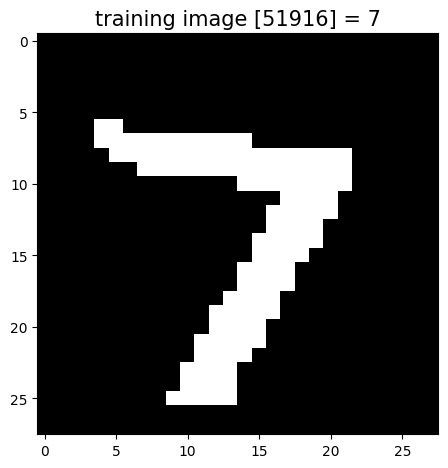

In [4]:
#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []

for i in range(0, 1):
    r = random.randint(1, 60000)

    img_2_show = x_train[r]
    img_2_show = (img_2_show > 50).astype(np.uint8)

    images_2_show.append(img_2_show)
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

# for i in range(0, 5):
#     r = random.randint(1, 10000)
#     images_2_show.append(x_test[r])        
#     titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

In [5]:
from IPython.display import clear_output
from ipywidgets import interact, FloatSlider

In [6]:
indices = random.sample(range(len(x_train)), 100)

def update(threshold):
    clear_output(wait=True)

    fig, axes = plt.subplots(10, 10, figsize=(10, 10))

    for ax, idx in zip(axes.ravel(), indices):
        img = (x_train[idx] > threshold).astype(np.uint8)

        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"{y_train[idx]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

interact(
    update,
    threshold=FloatSlider(value=90, min=0, max=255, step=1)
)

interactive(children=(FloatSlider(value=90.0, description='threshold', max=255.0, step=1.0), Output()), _dom_c…

<function __main__.update(threshold)>

In [7]:
def image_to_pulses(img, threshold=90):
    pulse_train = img.flatten()
    pulse_train = (pulse_train > threshold).astype(np.uint8)

    zeros = np.zeros(2 * len(pulse_train), dtype=np.uint8)
    zeros[::2] = pulse_train
    pulse_train = zeros

    pulse_train = pulse_train.reshape((28,28*2)).T

    return pulse_train

In [8]:
np.set_printoptions(threshold=np.inf)

idx =np.random.randint(0,3000)
print(image_to_pulses(x_train[idx]))
print(y_train[idx])

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

In [9]:
def get_images_pulses(batch_size = 600):
    random_idx = np.random.choice(len(x_train), size=batch_size, replace=False)

    x_batch = x_train[random_idx]
    y_batch = np.eye(11)[y_train[random_idx]]

    return x_batch, y_batch